# Homework 8: Nonlinear and Multivariate Modeling

This homework covers three lectures:
* **Lecture 22** (nonlinear curve fitting, `curve_fit`) -- Problems 1-3
* **Lecture 23** (multivariate linear regression) -- Problem 4
* **Lecture 24** (plotting functions of multiple variables) -- Problem 5

Problems 1-2 use small synthetic datasets generated in this notebook (clearly marked
and disclosed below -- realistic constants and noise, not real lab measurements).
Problem 3 uses `dataset_avrami` (synthetic, calibrated to a real textbook equation).
Problem 4 uses `dataset_concrete` (real data, already split into `x`/`y` for you).
Problem 5 reuses the 3D-printing dataset from Lectures 23-24.

## Submission instructions

Upload the `ipynb` file to Canvas:
> File -> Download -> ipynb -> upload to Canvas (like any other file)

*Only* the `ipynb` file type will be accepted.

Save a copy of the notebook right away to avoid losing your work!

# Problem 0 (0 pts): generative AI usage statement

As you work on this assignment, feel free to use generative AI tools to help you learn,
understand, and debug Python code. In particular, you could get hints or conceptual guidance in
the implementation you write yourself.

However, you must clearly disclose and cite all use of AI. You must include:
1. The name(s) of the AI tool(s) used.
2. The specific prompt(s) you used to generate the content.
3. A description of how you used the output and what edits or additions you made to integrate it
   into your own work.

You are fully responsible for the final submitted work -- critically evaluate, fact-check, and
verify all AI-generated content for validity. Failure to properly cite and disclose AI use
constitutes plagiarism under Penn State's Academic Integrity policy.

Write your disclosure (or "I did not use an AI tool for this assignment") in the cell below.

*your disclosure here*

# Problem 1 (20 pts): Arrhenius rate law

The rate constant of a thermally-activated process follows the Arrhenius relationship:
`k = A * exp(-Ea / (R*T))`, where `T` is temperature in kelvin, `R = 8.314` J/(mol*K),
`A` is a prefactor, and `Ea` is the activation energy in J/mol.

Run the cell below -- it generates a small **synthetic** dataset of measured rate
constants at eight temperatures, with realistic multiplicative measurement noise added
on top of a planted, disclosed `A`/`Ea`. You are not told the planted values; your job is
to recover them from the data, the same way you would from a real kinetics experiment.
Fit this well and Problem 2's synthetic data too, and you should land a very high R² --
keep that as your calibration point for a strong fit, the Lecture 19 way; real kinetics
and hardening data won't land that close, and that's the lesson, not a flaw.

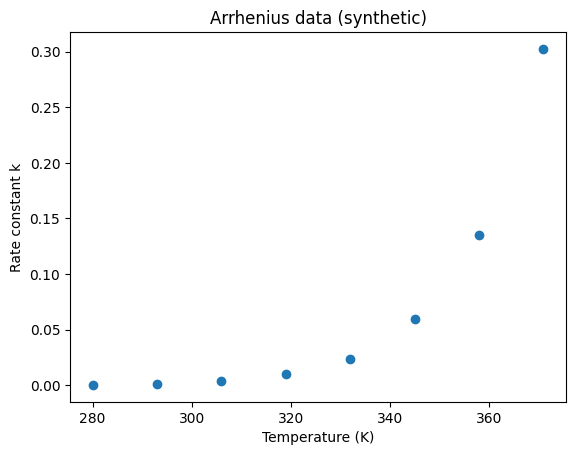

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

R_GAS = 8.314  # J/(mol K)

# --- SYNTHETIC DATA (disclosed): planted A, Ea + 3% multiplicative noise, seed=219 ---
rng = np.random.default_rng(219)
_A_true, _Ea_true = 4.2e8, 65000.0
T_k = np.array([280., 293., 306., 319., 332., 345., 358., 371.])
k_obs = _A_true * np.exp(-_Ea_true / (R_GAS * T_k)) * rng.normal(1.0, 0.03, size=T_k.shape)
# --- end synthetic data ---

plt.scatter(T_k, k_obs)
plt.xlabel('Temperature (K)'); plt.ylabel('Rate constant k')
plt.title('Arrhenius data (synthetic)')
plt.show()

(a) Write a Python function `arrhenius(T, A, Ea)` implementing `A * exp(-Ea / (R*T))`
(use `R_GAS` from above, don't hard-code `8.314` again).

(b) Fit it to `T_k`/`k_obs` with `curve_fit`. Rate constants like this typically span
several orders of magnitude while activation energies are usually tens of thousands of
J/mol -- look at your plot and pick a `p0` in that ballpark (order-of-magnitude is fine;
it does not need to be precise). Print the fitted `A` and `Ea`, each with its 1-sigma
uncertainty from `pcov` (same pattern as Lecture 22 Section 6).

(c) Compute and print R² for your fit.

(d) In 2-3 sentences: compare the *relative* uncertainty (uncertainty / fitted value) on
your `A` versus your `Ea`. One of the two is typically far less certain than the other,
even though R² is excellent. Why would a small error in `Ea` (which sits inside an
`exp()`) blow up into a much larger relative error in `A` than an equally-small absolute
error would for a parameter that enters linearly?

# Problem 2 (20 pts): power-law strain hardening

Many metals harden as they're plastically deformed, following the Hollomon relation:
`stress = K * strain^n`, where `K` is the strength coefficient (MPa) and `n` is the
strain-hardening exponent (typically 0.1-0.5 for metals). Another **synthetic** dataset,
same disclosure as Problem 1:

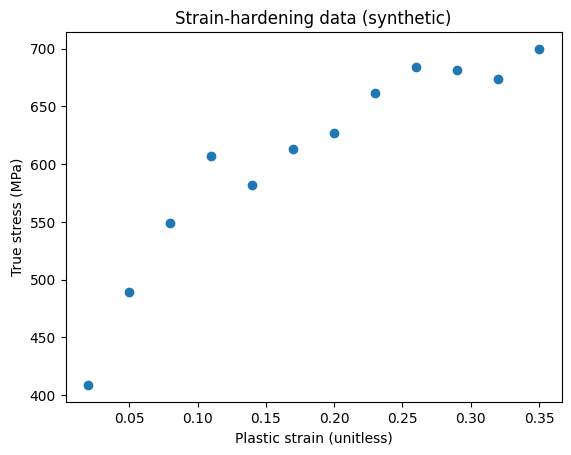

In [2]:
rng = np.random.default_rng(219)
_K_true, _n_true = 850.0, 0.18
strain = np.linspace(0.02, 0.35, 12)
stress_mpa = _K_true * strain**_n_true * rng.normal(1.0, 0.02, size=strain.shape)
# --- end synthetic data ---

plt.scatter(strain, stress_mpa)
plt.xlabel('Plastic strain (unitless)'); plt.ylabel('True stress (MPa)')
plt.title('Strain-hardening data (synthetic)')
plt.show()

(a) Write `hollomon(strain, K, n)` implementing `K * strain**n`.

(b) Fit it with `curve_fit`, choosing a reasonable `p0` from the plot (strength
coefficients for structural metals are typically a few hundred to a couple thousand MPa;
hardening exponents are usually between 0 and 1). Print fitted `K` and `n` with their
`pcov`-derived uncertainties.

(c) Compute and print R².

(d) A materials engineer tells you "an `n` close to 0 means the metal barely hardens as
it deforms; an `n` close to 1 means it hardens dramatically, almost linearly with
strain." Given your fitted `n`, is this alloy a strong or a weak strain-hardener? Is that
consistent with the shape of the scatter plot you made in (a)?

# Problem 3 (20 pts): Avrami (JMAK) phase transformation

Not every nonlinear model decays or grows without bound -- a phase transformation
*saturates*: it can't transform more than 100% of the material. The Johnson-Mehl-
Avrami-Kolmogorov equation describes this: `X(t) = 1 - exp(-k * t^n)`.

## Dataset: Avrami (JMAK) Isothermal Phase Transformation (synthetic, calibrated)

The Johnson-Mehl-Avrami-Kolmogorov (JMAK) equation describes how the fraction of
material transformed grows with time during an isothermal phase transformation
(recrystallization, crystallization, precipitation, ...):

X(t) = 1 - exp(-k * t^n)

This is the canonical MSE nonlinear-fitting example with a genuinely different
*shape* than an exponential decay or a power law: a sigmoid that saturates at
X=1. Fitting it with `curve_fit` is also a good `p0`-sensitivity exercise -- a
badly chosen starting guess for `n` traps the optimizer far from the true answer
(see the calibration note below).

**Why synthetic, not sourced.** The candidate real-data source (MSE2001python)
ships with no license, so nothing from it is reused here -- not even the shape of
the numbers. The JMAK equation itself is textbook materials-science kinetics;
only the (time, fraction_transformed) data are synthesized.

**Synthesis parameters (reproducible, seed=219):**
- 28 samples, times drawn (uniform, then sorted) across the window where the
  clean curve rises from X~0.05 to X~0.95
- planted parameters: k = 0.015, n = 2.5 (nucleation-and-growth regime, n in the
  textbook 2-3 range)
- Gaussian noise, std = 0.015, added to fraction_transformed; clipped to (0.001, 0.999)
  since it's a bounded [0,1] quantity
- **Verified:** `curve_fit(lambda t,k,n: 1-np.exp(-k*t**n), t, frac, p0=[0.01, 2])`
  recovers k ≈0.0155 (3.3% off the planted 0.015) and n ≈2.47 (1.1% off the
  planted 2.5), R^2 ≈0.998 -- well inside the "few %" / "R^2 >= 0.95" calibration
  requirement. A deliberately bad starting guess, `p0=[50, 0.001]` (an almost-flat
  starting curve), converges to nonsense (R^2 ≈0.0) instead of the true optimum --
  confirmed as the intended HW8 `p0` cautionary case. Full run in
  `docs/2026-07-22-new-dataset-verification.md`.

In [3]:
import os
import pandas as pd

_file = 'avrami_transformation.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

t = data['time_min']
frac = data['fraction_transformed']

print(f'{len(data)} samples, time {t.min():.2f}-{t.max():.2f} min, '
      f'fraction transformed {frac.min():.3f}-{frac.max():.3f}')
data.head()

28 samples, time 1.75-8.24 min, fraction transformed 0.066-0.963


,time_min,fraction_transformed
0,1.75,0.0824
1,1.80,0.0748
2,1.91,0.0661
3,1.97,0.0805
4,2.05,0.0888


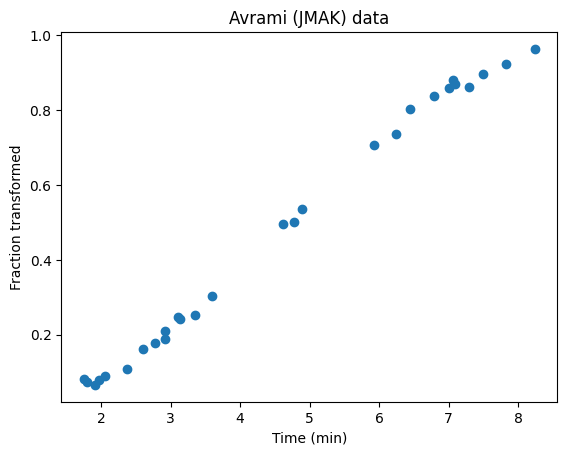

In [4]:
plt.scatter(t, frac)
plt.xlabel('Time (min)'); plt.ylabel('Fraction transformed')
plt.title('Avrami (JMAK) data')
plt.show()

(a) Write `jmak(t, k, n)` implementing `1 - exp(-k * t**n)`.

(b) Fit it with `curve_fit` using `p0=[0.01, 2]` (`n` in the 2-3 range is typical for a
nucleation-and-growth transformation). Print `k` and `n` with uncertainties, and R².

(c) Now refit the *same* data with a deliberately poor starting guess, `p0=[50, 0.001]`
(an almost-flat starting curve). Print the resulting parameters and R².

(d) In 2-3 sentences: did part (c)'s fit raise an error, a warning, or nothing at all?
Compare its R² to part (b)'s. What does this pair of fits teach you about trusting a
`curve_fit` call just because it ran without crashing?

# Problem 4 (20 pts): multivariate fit on concrete strength

`dataset_concrete` hands you `data` (the full table), plus `x` (a DataFrame of all 8
mixture-component and curing-age features) and `y` (compressive strength) already split
out for you -- the exact shape Lecture 23 used, just a different dataset.

## Dataset: Concrete Compressive Strength

We'll use a dataset of concrete compressive strengths for our examples.

Each row represents a concrete mixture. The 8 input columns are component
amounts (kg/m³) and curing age (days). The output is measured compressive
strength in MPa.

> Reuse of this database is unlimited with retention of copyright notice for
> Prof. I-Cheng Yeh and the following published paper:
> I-Cheng Yeh, "Modeling of strength of high performance concrete using artificial
> neural networks," Cement and Concrete Research, Vol. 28, No. 12, pp. 1797-1808 (1998)

In [5]:
import pandas as pd
import numpy as np
import os

_file = 'concrete.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# set up features (X) and target (y)
x = data.loc[:, 'Cement (component 1)(kg in a m^3 mixture)':'Age (day)']
y = data.loc[:, 'Concrete compressive strength(MPa, megapascals) ']

print(f'{len(data)} samples, {x.shape[1]} features')
data

1030 samples, 8 features


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


(a) Using Lecture 23's `fit_linear`/`LinearModel` pattern (copy the two definitions from
the lecture, or rewrite them -- they're six lines), fit `x`/`y` and print the intercept
and all 8 coefficients with their feature names, plus R².

(b) Standardize `x` the Lecture 23 way (`(x - x.mean()) / x.std()`), refit, and print the
standardized coefficients. Confirm R² is unchanged from part (a) (it should match to
several decimal places -- if it doesn't, you have a bug).

(c) Which standardized coefficient has the largest magnitude? In one sentence, does that
match physical intuition about what makes concrete strong (more of it, or less of it)?

(d) Split into train/test the Lecture 20/23 way (shuffle `data.index` once with
`np.random.default_rng(0)`, slice 75/25), refit `fit_linear` on the training data only,
and report train and test R² (`evaluate_model` from `eval_helpers`, or write your own
two-line version). Are train and test R² close together here, the way they were for the
3D-printing fit in lecture, or does this dataset behave differently? Suggest one reason
why (hint: compare the two datasets' row counts).

# Problem 5 (20 pts): visualizing a two-input model

Reuse `dataset_3dprinting` and fit a small model on `layer_height (mm)` and
`infill_density (%)` predicting `tension_strength (Mpa)` (same `fit_linear` pattern,
two feature columns instead of one).

## Dataset: 3D Printing (FDM) Parameters

Data come from [this github repository](https://github.com/ahmetokudan/3dprinterdeeplearning)
and are provided with an unlimited license (public domain).

In [6]:
import os
import pandas as pd

_file = '3dprinting.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data.head()  # show a view of the data file

,layer_height (mm),wall_thickness (mm),infill_density (%),infill_pattern,nozzle_temperature (degC),bed_temperature (degC),print_velocity (mm/s),material,fan_speed (%),roughness (microns),tension_strength (Mpa),elongation (%)
0,0.02,8,90,grid,220,60,40,abs,0,25,18,1.2
1,0.02,7,90,honeycomb,225,65,40,abs,25,32,16,1.4
2,0.02,1,80,grid,230,70,40,abs,50,40,8,0.8
3,0.02,4,70,honeycomb,240,75,40,abs,75,68,10,0.5
4,0.02,6,90,grid,250,80,40,abs,100,92,5,0.7


(a) Build a `np.meshgrid` spanning the observed range of both features (50 points each is
plenty) and evaluate your fitted model on the grid to get `Z`.

(b) Produce a filled contour plot (`plt.contourf`) of `Z` with a labeled colorbar, and
overlay the real data points colored by their actual `tension_strength (Mpa)` value.

(c) Produce a static Matplotlib 3D surface (`projection='3d'`, `ax.plot_surface`) of the
same `Z`, with the real data points scattered on top.

(d) Looking at your contour plot: is there a region of the grid where the model is
extrapolating far from any real data point? Point to it (in words -- which corner or
edge) and explain in one sentence why a prediction there deserves more skepticism than a
prediction near the middle of the data.

# Wrap-up

This homework asked for exactly what Lectures 22-24 built: define a nonlinear model
function and fit it with `curve_fit`, choosing `p0` deliberately rather than by accident
(Problems 1-3); fit and interpret a model with several predictors at once, on comparable
footing after standardizing (Problem 4); and look at a two-input model as a surface
instead of a table of numbers (Problem 5). Problem 3(c) and Problem 1(d) both made the
same point from different angles: a fit that runs without an error is not the same thing
as a fit you should trust. Always plot it, always check R², and always ask whether the
uncertainty on a parameter is small enough that the number means what you're about to
claim it means.